In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


In [14]:
REPO_ROOT = Path.home() / "EASM"
PROCESSED_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "outputs" / "som_u850"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [15]:
# =========================================================
# 0) input paths
# =========================================================
som_csv = OUTPUT_DIR / "som_daily_assignment.csv"
olr_file = PROCESSED_DIR / "olr_jja_1982_2025.nc"
out_fig = OUTPUT_DIR / "olr_anom_node_composites_sig2.png"

In [16]:
# =========================================================
# 1) SOM 일별 할당표 읽기
# =========================================================
df = pd.read_csv(som_csv)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

# node 1~9만 유지
df = df[df["node"].between(1, 9)].copy()
df = df.sort_values("date").drop_duplicates(subset="date")

In [17]:
# =========================================================
# 2) OLR 자료 읽기
# =========================================================
ds = xr.open_dataset(olr_file)
olr = ds["olr"]   # (time, lat, lon) 가정

# 좌표명 통일
rename_dict = {}
if "latitude" in olr.dims:
    rename_dict["latitude"] = "lat"
if "longitude" in olr.dims:
    rename_dict["longitude"] = "lon"
if rename_dict:
    olr = olr.rename(rename_dict)

# 길이 1짜리 차원 제거 (예: zlev, level 등)
olr = olr.squeeze(drop=True)

In [18]:
clim = olr.groupby("time.dayofyear").mean("time")
olr = olr.groupby("time.dayofyear") - clim

In [19]:
# =========================================================
# 3) 시간축을 pandas datetime으로 통일
# =========================================================
olr_time = pd.to_datetime(olr["time"].values).normalize()
olr = olr.assign_coords(time=olr_time)

In [20]:
# =========================================================
# 4) CSV와 NetCDF의 공통 날짜만 남김
# =========================================================
common_time = np.intersect1d(olr["time"].values, df["date"].values)

print("len(olr time)   =", olr.sizes["time"])
print("len(df date)    =", len(df))
print("len(common_time)=", len(common_time))

if len(common_time) == 0:
    raise ValueError("공통 날짜가 없습니다. olr time과 CSV date를 확인하세요.")

olr_sel = olr.sel(time=common_time)

node_map = (
    df.set_index("date")["node"]
      .reindex(pd.to_datetime(common_time))
)

valid = ~node_map.isna().to_numpy()
olr_sel = olr_sel.isel(time=valid)
node_vals = node_map.to_numpy()[valid].astype(int)

print("len(olr_sel time) =", olr_sel.sizes["time"])
print("len(node_vals)    =", len(node_vals))

if olr_sel.sizes["time"] == 0:
    raise ValueError("olr_sel의 time 길이가 0입니다.")

len(olr time)   = 4048
len(df date)    = 4048
len(common_time)= 4048
len(olr_sel time) = 4048
len(node_vals)    = 4048


In [21]:
# =========================================================
# 5) node를 xarray coordinate로 부여
# =========================================================
olr_sel = olr_sel.assign_coords(node=("time", node_vals))

In [22]:
# =========================================================
# 6) node별 composite 평균 / 표준편차 / 표본수
# =========================================================
comp = olr_sel.groupby("node").mean(dim="time")
std = olr_sel.groupby("node").std(dim="time")
n = olr_sel.groupby("node").count(dim="time")

# node 1~9 모두 유지
nodes_all = np.arange(1, 10)
comp = comp.reindex(node=nodes_all)
std = std.reindex(node=nodes_all)
n = n.reindex(node=nodes_all)

# 표준오차
se = std / np.sqrt(n)

In [23]:
# =========================================================
# 7) 2-sigma significance mask
#    |mean| >= 2 * SE
# =========================================================
sig2 = (np.abs(comp) >= 2.0 * se).fillna(False)

print(comp)
print(n)

<xarray.DataArray 'olr' (node: 9, lat: 73, lon: 144)> Size: 378kB
array([[[-2.22326562e-01, -2.23041072e-01, -2.10432693e-01, ...,
         -2.11492002e-01, -2.32620075e-01, -2.12055832e-01],
        [-4.70875710e-01, -3.92990202e-01, -4.15762633e-01, ...,
         -4.82248366e-01, -4.90135431e-01, -4.37162936e-01],
        [-2.09525898e-01, -1.60569102e-01, -1.43314660e-01, ...,
         -2.57046521e-01, -2.16257915e-01, -1.46605179e-01],
        ...,
        [-1.03793211e-01, -1.98719561e-01, -3.00999880e-01, ...,
          1.18892886e-01,  1.64588578e-02, -8.14135820e-02],
        [-1.22689083e-01, -4.64090928e-02, -2.25563288e-01, ...,
          2.92254835e-02,  7.14288801e-02, -1.88993141e-02],
        [ 1.35355741e-02,  7.07675761e-04, -2.15221662e-02, ...,
          2.99261212e-02,  1.24468040e-02,  1.17821964e-02]],

       [[-3.72832179e-01, -3.68768185e-01, -3.69874686e-01, ...,
         -3.70153308e-01, -3.78047764e-01, -3.76316071e-01],
        [-7.62836933e-01, -7.67539918

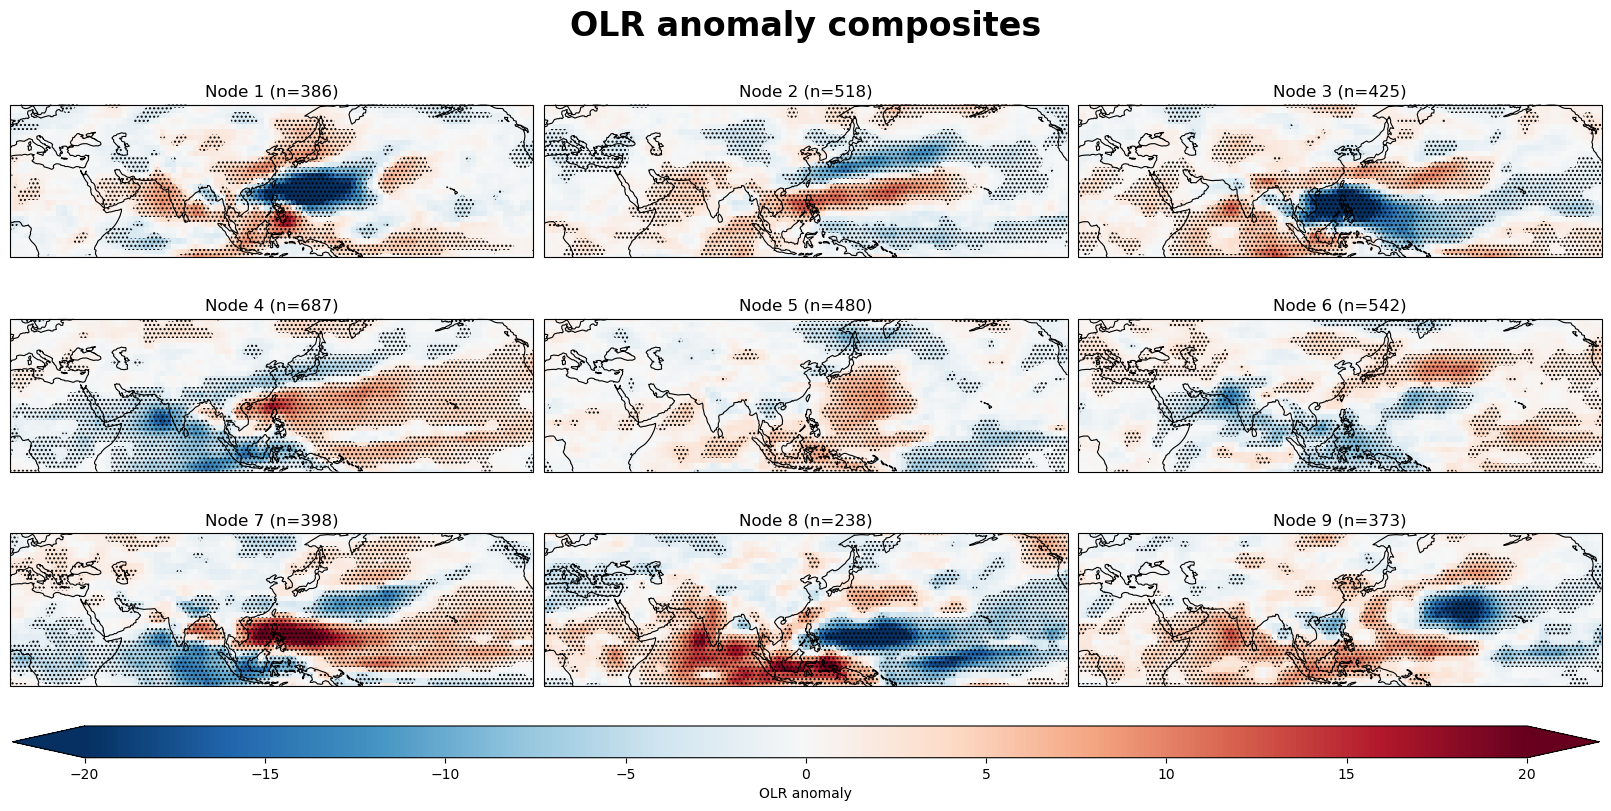

In [24]:
# =========================================================
# 8) Plot
# =========================================================
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    3, 3,
    figsize=(16, 8),
    layout="constrained",
    subplot_kw={"projection": proj}
)

pcm = None

for i, ax in enumerate(axes.flat, start=1):
    ax.set_extent([0, 240, -10, 60], crs=ccrs.PlateCarree())

    da = comp.sel(node=i).squeeze(drop=True)
    mask = sig2.sel(node=i).squeeze(drop=True)

    if np.isfinite(da.values).any():
        pcm = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            add_colorbar=False,
            cmap="RdBu_r",
            vmin=-20,
            vmax=20,
            extend="both",
        )

        # stipple/hatching
        ax.contourf(
            da["lon"].values,
            da["lat"].values,
            mask.astype(int).values,
            levels=[0.5, 1.5],
            hatches=["...."],
            colors="none",
            transform=ccrs.PlateCarree(),
        )

    ax.coastlines(linewidth=0.8)
    ax.set_title(f"Node {i} (n={int(np.nanmax(n.sel(node=i).values))})")

fig.suptitle("OLR anomaly composites", fontsize=24, fontweight="bold")

# 공통 colorbar
if pcm is not None:
    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        aspect=50,
        extend="both",
    )
    cbar.set_label("OLR anomaly")

plt.savefig(out_fig, dpi=144, bbox_inches="tight")
plt.show()